# SymPyによる微分方程式の解法：解析的アプローチの全貌

## 概要
物理学や工学、経済学など、時間とともに変化するシステムを記述する上で「微分方程式」は避けて通れないツールである。通常、複雑な微分方程式は数値計算（ルンゲ・クッタ法など）によって近似解を求めることが多いが、現象の本質的な理解には「解析解（厳密解）」の導出が不可欠である。

Pythonの数式処理ライブラリ **SymPy** は、強力な微分方程式ソルバー `dsolve` を備えており、常微分方程式（ODE）を記号的に解くことができる。本記事では、SymPyを用いて微分方程式を解くプロセスを、数式の変形過程とともに詳細に解説する。

具体的には、以下のトピックを扱う。

1. **1階常微分方程式**：変数分離形とニュートンの冷却の法則
2. **2階常微分方程式**：減衰振動子とその挙動分類
3. **連立微分方程式**：相互作用するシステム

### 筆者の環境
筆者の実行環境は以下の通りである。

In [1]:
!sw_vers

ProductName:		macOS
ProductVersion:		15.5
BuildVersion:		24F74


In [2]:
!python -V

Python 3.12.12


必要なライブラリをインポートする。

In [3]:
import sympy
from sympy import symbols, Function, dsolve, Eq, Derivative, sin, cos, exp, sqrt, solve, classify_ode, checkodesol, Matrix
from sympy.abc import t # 時間変数 t をインポート
from pprint import pprint as py_pprint

# 数式をLaTeX形式で綺麗に表示するための設定
sympy.init_printing()

print("sympy version :", sympy.__version__)

sympy version : 1.14.0


## 1. 1階常微分方程式：ニュートンの冷却の法則

まずは基本的な1階の微分方程式として、「ニュートンの冷却の法則」を取り上げる。これは、物体の温度変化の速度が、物体と周囲の温度差に比例するという法則である。

### 1.1 方程式の定式化

物体の温度を $T(t)$、周囲の温度（一定）を $T_{env}$、冷却定数を $k (>0)$ とすると、方程式は以下のように記述される。

$$ \frac{dT(t)}{dt} = -k (T(t) - T_{env}) $$

SymPyでこの方程式を定義する。

In [4]:
T = Function('T')
k = symbols('k', real=True, positive=True)
T_env = symbols('T_{env}', real=True)

# 微分方程式の定義 Eq(左辺, 右辺)
ode_cooling = Eq(T(t).diff(t), -k * (T(t) - T_env))

print("微分方程式:")
sympy.pprint(ode_cooling)

微分方程式:
d                              
──(T(t)) = -k⋅(-T_{env} + T(t))
dt                             


### 1.2 一般解の導出

この方程式は変数分離形であり、手計算では以下のように解く。

$$ \frac{dT}{T - T_{env}} = -k dt $$

両辺を積分して、

$$ \ln |T - T_{env}| = -kt + C $$

$$ T(t) = T_{env} + C' e^{-kt} $$

SymPyの `dsolve` 関数を用いて、この一般解を一発で求めてみよう。

In [5]:
sol_general = dsolve(ode_cooling, T(t))

print("一般解:")
sympy.pprint(sol_general)

一般解:
           -k⋅t          
T(t) = C₁⋅ℯ     + T_{env}


結果には積分定数 $C_1$ が含まれている。

### 1.3 初期条件の適用

初期時刻 $t=0$ における温度を $T_0$ とする初期条件 $T(0) = T_0$ を適用する。
SymPyでは `ics` (Initial Conditions) 引数を用いて初期条件を指定できる。

In [6]:
T0 = symbols('T_0', real=True)

# 初期条件付きで解く
sol_particular = dsolve(ode_cooling, T(t), ics={T(0): T0})

print("特解（初期条件適用後）:")
sympy.pprint(sol_particular)

特解（初期条件適用後）:
                                 -k⋅t
T(t) = T_{env} + (T₀ - T_{env})⋅ℯ    


得られた解は以下の通りである。

$$ T(t) = T_{env} + (T_0 - T_{env}) e^{-kt} $$

時間が経過するにつれて（$t \to \infty$）、第2項が減衰し、物体の温度が周囲温度 $T_{env}$ に収束していく様子が数式から読み取れる。

## 2. 2階常微分方程式：減衰振動子

次に、物理学で極めて重要な「減衰振動子（Damped Harmonic Oscillator）」を扱う。これはバネ定数 $k$、質量 $m$、減衰係数 $c$ を持つ系の方程式である。

### 2.1 方程式の定式化

変位を $x(t)$ とすると、運動方程式は以下となる。

$$ m \frac{d^2x(t)}{dt^2} + c \frac{dx(t)}{dt} + k x(t) = 0 $$

簡単のため、ここでは $m=1$ とし、パラメータを $\gamma$ (減衰項) と $\omega_0$ (固有角振動数) を用いて書き換えることが一般的だが、SymPyの処理能力を示すために、生のパラメータのまま解いてみる。

In [7]:
x = Function('x')
m = symbols('m', real=True, positive=True)
c = symbols('c', real=True, positive=True)
k_spring = symbols('k', real=True, positive=True) # 前のセクションのkと区別

ode_harmonic = Eq(m * x(t).diff(t, 2) + c * x(t).diff(t) + k_spring * x(t), 0)

print("減衰振動の方程式:")
sympy.pprint(ode_harmonic)

減衰振動の方程式:
                         2           
  d                     d            
c⋅──(x(t)) + k⋅x(t) + m⋅───(x(t)) = 0
  dt                      2          
                        dt           


### 2.2 一般解の導出

この方程式の解の挙動は、判別式 $D = c^2 - 4mk$ の符号によって「過減衰」「臨界減衰」「減衰振動」に分類される。SymPyにそのまま解かせてみよう。

In [8]:
sol_harmonic = dsolve(ode_harmonic, x(t))

print("一般解:")
sympy.pprint(sol_harmonic)

一般解:
             ⎛        ____________⎞          ⎛       ____________⎞ 
             ⎜       ╱  2         ⎟          ⎜      ╱  2         ⎟ 
           t⋅⎝-c + ╲╱  c  - 4⋅k⋅m ⎠       -t⋅⎝c + ╲╱  c  - 4⋅k⋅m ⎠ 
           ────────────────────────       ─────────────────────────
                     2⋅m                             2⋅m           
x(t) = C₁⋅ℯ                         + C₂⋅ℯ                         


解には $\sqrt{c^2 - 4km}$ という項が含まれており、これが実数か虚数かによって挙動が変わることが示唆されている。

### 2.3 具体的なケース：減衰振動（不足減衰）

具体的な数値を代入して、振動する解を確認してみよう。
$m=1, k=1$ (固有振動数 $\omega_0=1$) とし、$c=0.2$ (弱い減衰) とする。

In [9]:
ode_underdamped = ode_harmonic.subs({m: 1, k_spring: 1, c: 0.2})

# 初期条件: x(0)=1 (初期変位), x'(0)=0 (初速度0)
ics = {x(0): 1, x(t).diff(t).subs(t, 0): 0}

sol_underdamped = dsolve(ode_underdamped, x(t), ics=ics)

print("不足減衰の解:")
sympy.pprint(sol_underdamped)

不足減衰の解:
                                                                               ↪
x(t) = (0.100503781525921⋅sin(0.99498743710662⋅t) + 1.0⋅cos(0.99498743710662⋅t ↪

↪     -0.1⋅t
↪ ))⋅ℯ      


解は $e^{-0.1t} (1.005 \cos(0.995t) + 0.101 \sin(0.995t))$ のような形となり、指数関数的な減衰項と、三角関数の振動項の積になっていることがわかる。

## 3. 連立微分方程式

最後に、複数の変数が相互に作用する連立微分方程式を扱う。例として、以下の線形システムを考える。

$$ \begin{cases} \frac{dx}{dt} = -2x + y \\ \frac{dy}{dt} = x - 2y \end{cases} $$

これは、2つのタンク間で液体が行き来するような拡散モデルに対応する。

連立微分方程式:


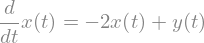

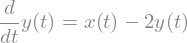

In [11]:
y = Function('y')

eq1 = Eq(x(t).diff(t), -2*x(t) + y(t))
eq2 = Eq(y(t).diff(t), x(t) - 2*y(t))

system = [eq1, eq2]

print("連立微分方程式:")
for eq in system:
    # sympy.pprint(eq)

    display(eq)

### 3.1 システムの解法

`dsolve` に方程式のリストと関数のリストを渡すことで、連立方程式を解くことができる。

In [ ]:
sol_system = dsolve(system, [x(t), y(t)])

print("連立方程式の解:")
for sol in sol_system:
    sympy.pprint(sol)

解は以下のような形式になる。

$$ x(t) = -C_1 e^{-3t} + C_2 e^{-t} $$
$$ y(t) = C_1 e^{-3t} + C_2 e^{-t} $$

ここで、固有値 $\lambda = -1, -3$ に対応する指数関数項が現れていることがわかる。行列形式で書けば、係数行列 $\mathbf{A} = \begin{pmatrix} -2 & 1 \\ 1 & -2 \end{pmatrix}$ の固有値が $-1, -3$ であることと対応している。

SymPyで固有値を確認してみよう。

In [ ]:
A = Matrix([[-2, 1], [1, -2]])
eigenvals = A.eigenvals()

print("係数行列の固有値:")
py_pprint(eigenvals)

固有値が $\{-3: 1, -1: 1\}$ （値: 重複度）であることが確認できた。これにより、微分方程式の解の構造が行列の固有値問題と密接に関連していることが、SymPyを通じて明確に理解できる。

## 結論

この記事では、SymPyを用いて常微分方程式（ODE）を解析的に解く方法を解説した。

1階の変数分離形から始まり、2階の減衰振動子、そして連立微分方程式に至るまで、`dsolve` 関数一つで統一的に解を導出できることを示した。また、初期条件の適用や、解の構造と固有値との関係など、数式処理ライブラリならではの深い洞察が得られることも確認した。

微分方程式は自然現象を記述する言語である。SymPyを使いこなすことで、その言語をより深く、正確に読み解くことができるようになるだろう。

### 参考文献
- [SymPy Documentation: ODE](https://docs.sympy.org/latest/modules/solvers/ode.html)

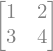

In [12]:
from sympy import Matrix, symbols
from IPython.display import display

x, y = symbols('x y')
A = Matrix([[1,2],[3,4]])
display(A)  # 自動でLaTeX表示